# Benchmark Algorithms & Solutions

# Imports

In [19]:
import time
import tracemalloc
import psutil, os
import platform, subprocess, re
import os, time, tracemalloc, psutil, platform, math, json, base64, io
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Other Setup

In [20]:
#@title ⏳ System Info
#!pip -q install psutil pandas matplotlib


def system_info():
    info = {
        "python": platform.python_version(),
        "os": platform.platform(),
        "machine": platform.machine(),
        "cpu_logical": psutil.cpu_count(logical=True),
        "cpu_physical": psutil.cpu_count(logical=False),
        "ram_GB": round(psutil.virtual_memory().total / 1e9, 2),
        "gpu": "None / Not available",
    }
    # Try to read GPU info (Colab GPU runtime only)
    try:
        import subprocess
        out = subprocess.check_output(
            ["nvidia-smi","--query-gpu=name,memory.total","--format=csv,noheader"],
            text=True
        ).strip()
        if out:
            info["gpu"] = out
    except Exception:
        pass
    return info

print("==== System Info ====")
print(json.dumps(system_info(), indent=2))

def profile_call(fn, *args, **kwargs):
    """
    Profile a function call and return:
    (result, time_s, peak_tracemalloc_MB, rss_delta_MB)
    """
    process = psutil.Process(os.getpid())
    rss_before = process.memory_info().rss / (1024**2)
    tracemalloc.start()
    t0 = time.perf_counter()
    result = fn(*args, **kwargs)
    t1 = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    rss_after = process.memory_info().rss / (1024**2)
    return result, (t1 - t0), (peak / (1024**2)), max(0.0, rss_after - rss_before)
    
def profile_fast(func, *args, **kwargs):
    """
    Runs func(*args, **kwargs) and returns:
    (result, time_seconds, rss_delta_MB)

    rss_delta_MB = change in process RSS during the call.
    """
    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss / 1024**2
    
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()
    
    mem_after = process.memory_info().rss / 1024**2

    return result, (end - start), (mem_after - mem_before)

def profile_fast_precise(func, *args, **kwargs):
    process = psutil.Process(os.getpid())

    tracemalloc.start()
    start = time.perf_counter()

    result = func(*args, **kwargs)

    end = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Convert bytes → MB
    peak_MB = peak / (1024**2)

    return result, (end - start), peak_MB
    
def profile_light(func, *args, **kwargs):
    start = time.perf_counter()
    result = func(*args, **kwargs)
    end = time.perf_counter()
    return result, (end - start), 0.0   # no memory cost

def profile_timing_only(fn, *args, **kwargs):
    t0 = time.perf_counter()
    result = fn(*args, **kwargs)
    t1 = time.perf_counter()
    return result, (t1 - t0), 0.0   # no memory measurement



==== System Info ====
{
  "python": "3.12.3",
  "os": "Windows-10-10.0.19045-SP0",
  "machine": "AMD64",
  "cpu_logical": 8,
  "cpu_physical": 4,
  "ram_GB": 17.1,
  "gpu": "NVIDIA GeForce GTX 1060 6GB, 6144 MiB"
}


# Resolve output inconsistencies

In [32]:
def normalize_algo_output(raw, algo_name=""):
    """
    Converts ANY structure from ANY algorithm into the standard
    format expected by the benchmark runner.
    """

    # ---------------------------------------------
    # Case 1: Dictionary-based output
    # ---------------------------------------------
    if isinstance(raw, dict):
        labels = raw.get("labels")
        quality = raw.get("quality") or raw.get("score") or raw.get("k")
        stats = raw.get("stats", {})
        return {"labels": labels, "quality": quality, "stats": stats}

    # ---------------------------------------------
    # Case 2: Tuple/list-based outputs
    # ---------------------------------------------
    if isinstance(raw, (list, tuple)):

        # ----- CASE: InferredApproach (6 items) -----
        if len(raw) == 6:
            L1, L2, L3, seen, unused, stats = raw
            labels = list(L1) + list(L2) + list(L3)
            quality = max(labels)
            return {"labels": labels, "quality": quality, "stats": stats}

        # ----- CASE: Branch & Bound (4 items) -----
        if len(raw) == 4:
            m, labels_dict, B, used_sums = raw

            # flatten labels in deterministic order
            try:
                # Sort vertex names like v1_1, v1_2, ..., or natural sort
                labels = [labels_dict[k] for k in sorted(labels_dict.keys())]
            except:
                # fallback: unsorted values
                labels = list(labels_dict.values())

            stats = {
                "edges": m,
                "used_sums": len(used_sums)
            }

            return {"labels": labels, "quality": B, "stats": stats}

        # ----- CASE: Simple graph-based algorithms returning (labels, score) -----
        if len(raw) == 2:
            labels, q = raw
            return {"labels": labels, "quality": q, "stats": {}}
        
        # ----- CASE: Labels-only algorithm -----
        # e.g. [1,1,2,6,3,...] directly returned
        if all(isinstance(x, int) for x in raw):
            labels = list(raw)
            quality = max(labels)            # EIS = max vertex label
            return {"labels": labels, "quality": quality, "stats": {}}

    # ---------------------------------------------
    # Unsupported format
    # ---------------------------------------------
    raise ValueError(f"Unknown output format from algorithm '{algo_name}': {raw}")


# Benchmark

In [22]:
def run_algo_bench(algos, n_values, repeats=1):
    rows = []
    env = system_info()

    for n in n_values:
        print(f"\n📐 n = {n}")

        for name, entry in algos.items():

            # Support simple format:  "name": func
            if callable(entry):
                algo = entry
                profiler = profile_fast_precise
    
            # Preferred format:  "name": {"fn": func, "profiler": profiler_fn}
            else:
                algo = entry["fn"]
                profiler = entry.get("profiler", profile_fast_precise)

            t_acc = 0
            rss_acc = 0
            qualities = []
            last_stats = {}
            last_norm = None

            for _ in range(repeats):
                raw, t, rss = profiler(algo, n)
                norm = normalize_algo_output(raw, name)

                t_acc += t
                rss_acc += rss
                qualities.append(norm["quality"])
                last_stats = norm["stats"]
                last_norm = norm

            # Quality metrics
            q_min = float(np.min(qualities))
            q_max = float(np.max(qualities))
            q_mean = float(np.mean(qualities))
            q_med = float(np.median(qualities))
            q_std = float(np.std(qualities))

            # Label metrics
            labels = last_norm["labels"]
            if labels:
                lbl_min = min(labels)
                lbl_max = max(labels)
                lbl_range = lbl_max - lbl_min
                lbl_count = len(labels)
            else:
                lbl_min = lbl_max = lbl_range = lbl_count = None

            rows.append({
                "method": name,
                "n": n,

                # Timing + memory
                "time_s": t_acc / repeats,
                "rss_MB": rss_acc / repeats,

                # Quality statistics
                "quality_min": q_min,
                "quality_max": q_max,
                "quality_mean": q_mean,
                "quality_median": q_med,
                "quality_std": q_std,

                # Label metrics
                "edge_irregularity": lbl_max,
                "label_min": lbl_min,
                "label_max": lbl_max,
                "label_range": lbl_range,
                "num_labels": lbl_count,

                "stats": last_stats,

                # System info
                "python": env["python"],
                "cpu_logical": env["cpu_logical"],
                "ram_GB": env["ram_GB"],
                "gpu": env["gpu"],
            })

            print(f"  → {name}: "
                  f"time={t_acc/repeats:.4f}s, "
                  f"ΔRSS={rss_acc/repeats:.4f}MB, "
                  f"Q={q_med:.2f}")

    return pd.DataFrame(rows)


# Algorithms

## P1 Inferred Aproach

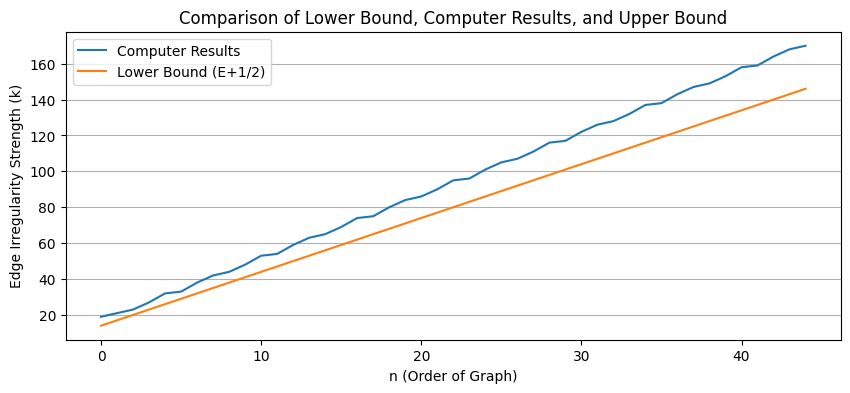

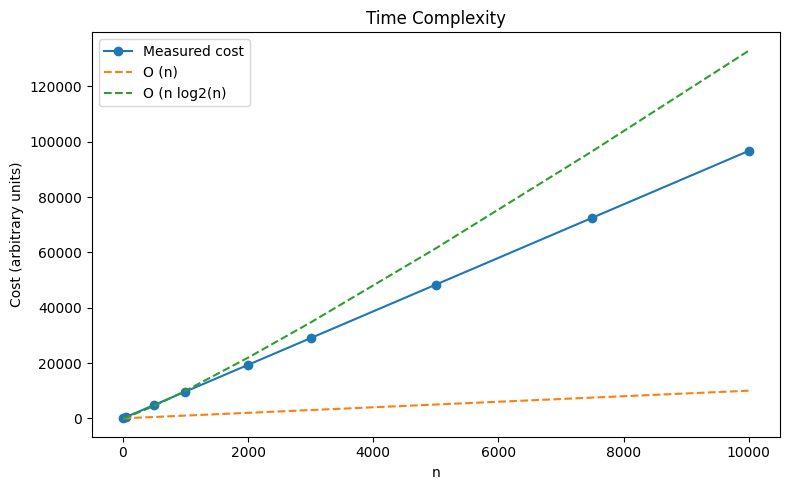

In [23]:
%run P1_InferredApproach.ipynb

#Can reuse w/ InferredApproach()

In [24]:
def algo_inferred(n):
    return InferredApproach(n)


## P1_P2 Branch and Bound - Updated

In [25]:
%run "P1_P2 Branch and Bound - Updated Version.ipynb"

In [26]:
def mongolian_branchbound(n):
    return Branch_Bound(n, graph_type = 1)

def stargraph1BND(n):
    return Branch_Bound(n, graph_type = 2)

def stargraph2BND(n):
    return Branch_Bound(n, graph_type = 3)

def stargraph3BND(n):
    return Branch_Bound(n, graph_type = 3)

## Greedy Labeler

In [27]:
%run "P2 Greedy Labeler.ipynb"

Detected graph chain length: 3
Min-k: 23, Max-Label: 27, Diff: 4
Labels: 1,1,2,6,3,8,16,11,4,5,5,10,14,9,16,24,16,11,12,8,21,16,23,20,24,27,24,22,
Edges: 2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,32,33,34,35,36,37,38,39,40,41,44,46,47,48,49,50,


---
config:
  layout: fixed
---
flowchart LR
    V0[[1]]
    V1[[1]]
    V2[[2]]
    V3[[6]]
    V4[[3]]
    V5[[8]]
    V6[[16]]
    V7[[11]]
    V8[[4]]
    V9[[5]]
    V10[[5]]
    V11[[10]]
    V12[[14]]
    V13[[9]]
    V14[[16]]
    V15[[24]]
    V16[[16]]
    V17[[11]]
    V18[[12]]
    V19[[8]]
    V20[[21]]
    V21[[16]]
    V22[[23]]
    V23[[20]]
    V24[[24]]
    V25[[27]]
    V26[[24]]
    V27[[22]]
    V0<-->|2|V1
    V0<-->|4|V4
    V0<-->|5|V8
    V1<-->|3|V2
    V1<-->|6|V9
    V2<-->|8|V3
    V2<-->|10|V5
    V2<-->|7|V10
    V2<-->|11|V13
    V2<-->|13|V17
    V3<-->|9|V4
    V3<-->|22|V6
    V4<-->|14|V7
    V5<-->|19|V7
    V5<-->|12|V8
    V6<-->|20|V8
    V6<-->|21|V9
    V7<-->|16|V9

In [35]:
def stargraph1Greedy(n):
    graph = GraphBuilder.BuildGraph1Chain(n)
    labeler = GraphLabeler(graph)
    labels = labeler.SolveLabels()
    return labeler.SolveLabels()

def stargraph2Greedy(n):
    graph = GraphBuilder.BuildGraph2Chain(n)
    labeler = GraphLabeler(graph)
    labels = labeler.SolveLabels()
    return labeler.SolveLabels()

def stargraph3Greedy(n):
    graph = GraphBuilder.BuildGraph3Chain(n)
    labeler = GraphLabeler(graph)
    labels = labeler.SolveLabels()
    return labeler.SolveLabels()

# Run Benchmark

In [36]:

#Benchmarking mongolian tent graph algo
ALGORITHMS = {
    "Inferred": {
        "fn": algo_inferred,
        "profiler": profile_fast_precise,   # detailed profiling OK for fast constructive algorithm
        "repeats": 5                        # stable + fast, so multiple repeats fine
    },
    # Branch and bound super slow for mongolian tent
    #"BranchBound": { 
    #    "fn": mongolian_branchbound,
    #    "profiler": profile_timing_only,    # CRITICAL: no tracemalloc, no psutil — pure timing
    #    "repeats": 1                        # expensive: single run per n is appropriate
    #},
    #     "stargraph1_BND": {
    #         "fn": stargraph1BND,
    #         "profiler": profile_timing_only,   # CRITICAL: no tracemalloc, no psutil — pure timing
    #         "repeats": 3                        # not always stable
    # },
    #     "stargraph2_BND": {
    #         "fn": stargraph2BND,
    #         "profiler": profile_timing_only,   # CRITICAL: no tracemalloc, no psutil — pure timing
    #         "repeats": 3                        # not always stable
    # },
    #     "stargraph3_BND": {
    #         "fn": stargraph3BND,
    #         "profiler": profile_timing_only,   # CRITICAL: no tracemalloc, no psutil — pure timing
    #         "repeats": 3                        # not always stable
    # },
        "stargraph1Greedy": {
            "fn": stargraph1Greedy,
            "profiler": profile_timing_only,   # CRITICAL: no tracemalloc, no psutil — pure timing
            "repeats": 3                        # not always stable
    },
            "stargraph2Greedy": {
            "fn": stargraph2Greedy,
            "profiler": profile_timing_only,   # CRITICAL: no tracemalloc, no psutil — pure timing
            "repeats": 3                        # not always stable
    },
            "stargraph3Greedy": {
            "fn": stargraph3Greedy,
            "profiler": profile_timing_only,   # CRITICAL: no tracemalloc, no psutil — pure timing
            "repeats": 3                        # not always stable
    },
}


In [37]:
N_VALUES = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, ]

df = run_algo_bench(ALGORITHMS, N_VALUES)
df



📐 n = 10
  → Inferred: time=0.0003s, ΔRSS=0.0033MB, Q=33.00
  → stargraph1Greedy: time=0.0019s, ΔRSS=0.0000MB, Q=78.00
  → stargraph2Greedy: time=0.0018s, ΔRSS=0.0000MB, Q=78.00
  → stargraph3Greedy: time=0.0018s, ΔRSS=0.0000MB, Q=76.00

📐 n = 20
  → Inferred: time=0.0005s, ΔRSS=0.0109MB, Q=69.00
  → stargraph1Greedy: time=0.0060s, ΔRSS=0.0000MB, Q=155.00
  → stargraph2Greedy: time=0.0044s, ΔRSS=0.0000MB, Q=155.00
  → stargraph3Greedy: time=0.0043s, ΔRSS=0.0000MB, Q=155.00

📐 n = 30
  → Inferred: time=0.0007s, ΔRSS=0.0109MB, Q=105.00
  → stargraph1Greedy: time=0.0102s, ΔRSS=0.0000MB, Q=228.00
  → stargraph2Greedy: time=0.0086s, ΔRSS=0.0000MB, Q=228.00
  → stargraph3Greedy: time=0.0045s, ΔRSS=0.0000MB, Q=229.00

📐 n = 40
  → Inferred: time=0.0005s, ΔRSS=0.0108MB, Q=138.00
  → stargraph1Greedy: time=0.0138s, ΔRSS=0.0000MB, Q=303.00
  → stargraph2Greedy: time=0.0156s, ΔRSS=0.0000MB, Q=303.00
  → stargraph3Greedy: time=0.0118s, ΔRSS=0.0000MB, Q=305.00

📐 n = 50
  → Inferred: time=0.0008s,

,method,n,time_s,rss_MB,quality_min,quality_max,quality_mean,quality_median,quality_std,edge_irregularity,label_min,label_max,label_range,num_labels,stats,python,cpu_logical,ram_GB,gpu
0,Inferred,10,0.000329,0.003334,33.0,33.0,33.0,33.0,0.0,33,2,33,31,30,"{'while_next_free': 7, 'while_take_cursor': 47...",3.12.3,8,17.1,"NVIDIA GeForce GTX 1060 6GB, 6144 MiB"
1,stargraph1Greedy,10,0.001936,0.000000,78.0,78.0,78.0,78.0,0.0,78,1,78,77,91,{},3.12.3,8,17.1,"NVIDIA GeForce GTX 1060 6GB, 6144 MiB"
2,stargraph2Greedy,10,0.001839,0.000000,78.0,78.0,78.0,78.0,0.0,78,1,78,77,91,{},3.12.3,8,17.1,"NVIDIA GeForce GTX 1060 6GB, 6144 MiB"
3,stargraph3Greedy,10,0.001786,0.000000,76.0,76.0,76.0,76.0,0.0,76,1,76,75,91,{},3.12.3,8,17.1,"NVIDIA GeForce GTX 1060 6GB, 6144 MiB"
4,Inferred,20,0.000544,0.010902,69.0,69.0,69.0,69.0,0.0,69,2,69,67,60,"{'while_next_free': 11, 'while_take_cursor': 1...",3.12.3,8,17.1,"NVIDIA GeForce GTX 1060 6GB, 6144 MiB"
5,stargraph1Greedy,20,0.005961,0.000000,155.0,155.0,155.0,155.0,0.0,155,1,155,154,181,{},3.12.3,8,17.1,"NVIDIA GeForce GTX 1060 6GB, 6144 MiB"
6,stargraph2Greedy,20,0.004424,0.000000,155.0,155.0,155.0,155.0,0.0,155,1,155,154,181,{},3.12.3,8,17.1,"NVIDIA GeForce GTX 1060 6GB, 6144 MiB"
7,stargraph3Greedy,20,0.004261,0.000000,155.0,155.0,155.0,155.0,0.0,155,1,155,154,181,{},3.12.3,8,17.1,"NVIDIA GeForce GTX 1060 6GB, 6144 MiB"
8,Inferred,30,0.000740,0.010902,105.0,105.0,105.0,105.0,0.0,105,2,105,103,90,"{'while_next_free': 17, 'while_take_cursor': 1...",3.12.3,8,17.1,"NVIDIA GeForce GTX 1060 6GB, 6144 MiB"
9,stargraph1Greedy,30,0.010209,0.000000,228.0,228.0,228.0,228.0,0.0,228,1,228,227,271,{},3.12.3,8,17.1,"NVIDIA GeForce GTX 1060 6GB, 6144 MiB"


# Analysis

RSS_MB not tracked in all profiles! need to make graphs prettier/better

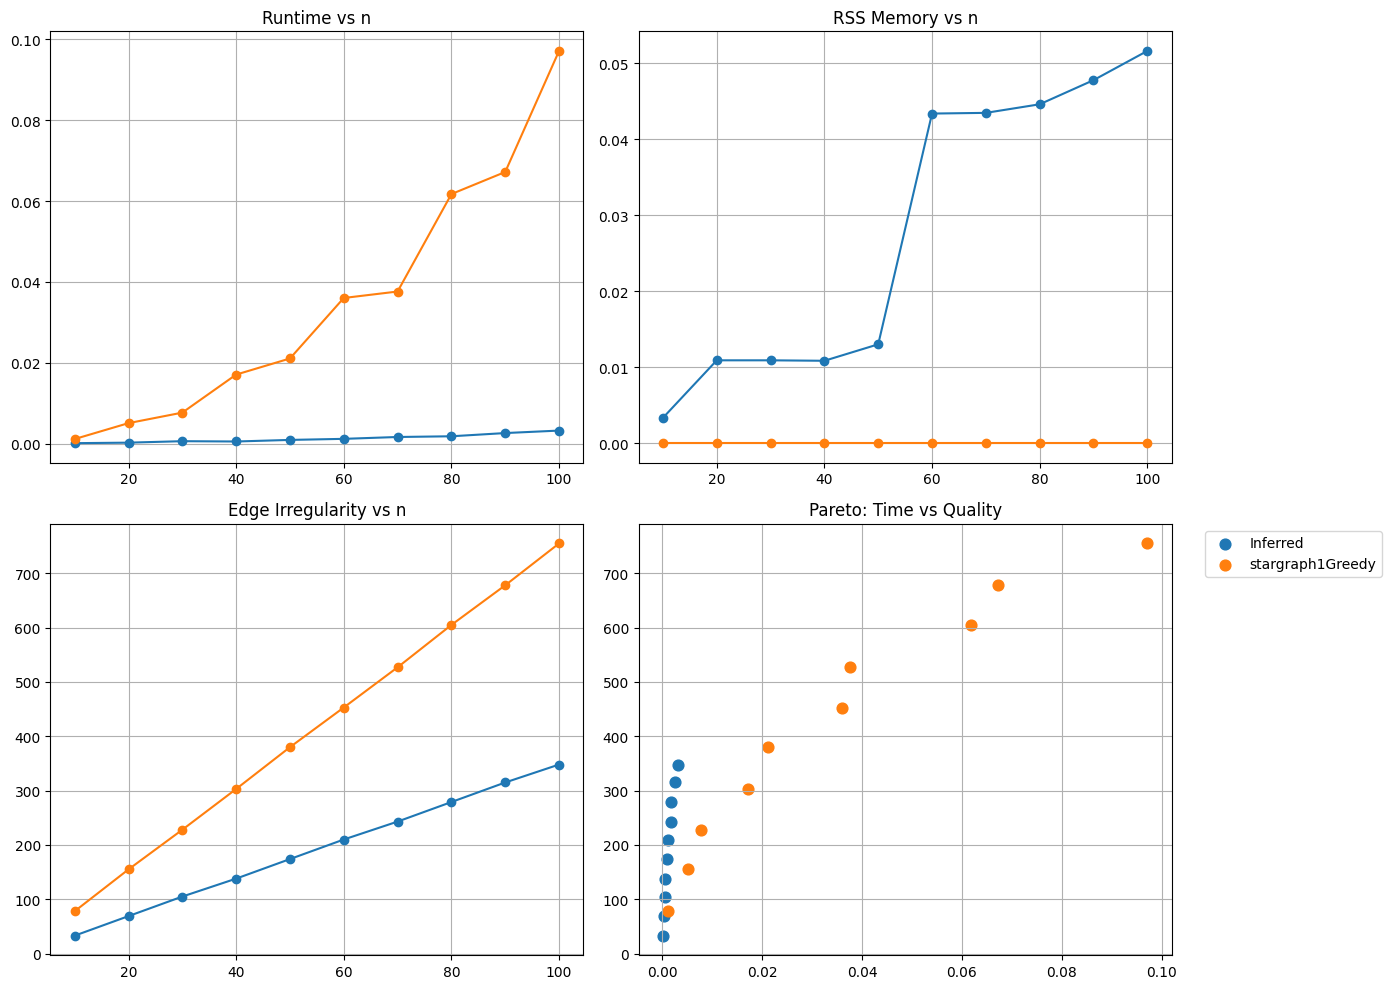

In [34]:
fig, axs = plt.subplots(2, 2, figsize=(14,10))

# Runtime
for method in df["method"].unique():
    sub = df[df["method"] == method]
    axs[0,0].plot(sub["n"], sub["time_s"], marker="o", label=method)
axs[0,0].set_title("Runtime vs n")
axs[0,0].grid(True)

# Memory
for method in df["method"].unique():
    sub = df[df["method"] == method]
    axs[0,1].plot(sub["n"], sub["rss_MB"], marker="o", label=method)
axs[0,1].set_title("RSS Memory vs n")
axs[0,1].grid(True)

# Edge Irregularity
for method in df["method"].unique():
    sub = df[df["method"] == method]
    axs[1,0].plot(sub["n"], sub["edge_irregularity"], marker="o", label=method)
axs[1,0].set_title("Edge Irregularity vs n")
axs[1,0].grid(True)

# Pareto
for method in df["method"].unique():
    sub = df[df["method"] == method]
    axs[1,1].scatter(sub["time_s"], sub["edge_irregularity"], s=60, label=method)
axs[1,1].set_title("Pareto: Time vs Quality")
axs[1,1].grid(True)

plt.legend(bbox_to_anchor=(1.05, 1.0))
plt.tight_layout()
plt.show()
